Starting Inference...
----------------------------------------
⏱️  [Inference Profiling]
Min Time:  0.3837 ms
Max Time:  5.7880 ms
Avg Time:  0.6651 ms
Avg Steps: 3.70 packets before early exit
----------------------------------------
📊 [Classification Metrics (Threshold = 0.5)]
Accuracy:  0.7960
Precision: 0.7102
Recall:    1.0000
F1 Score:  0.8306
----------------------------------------


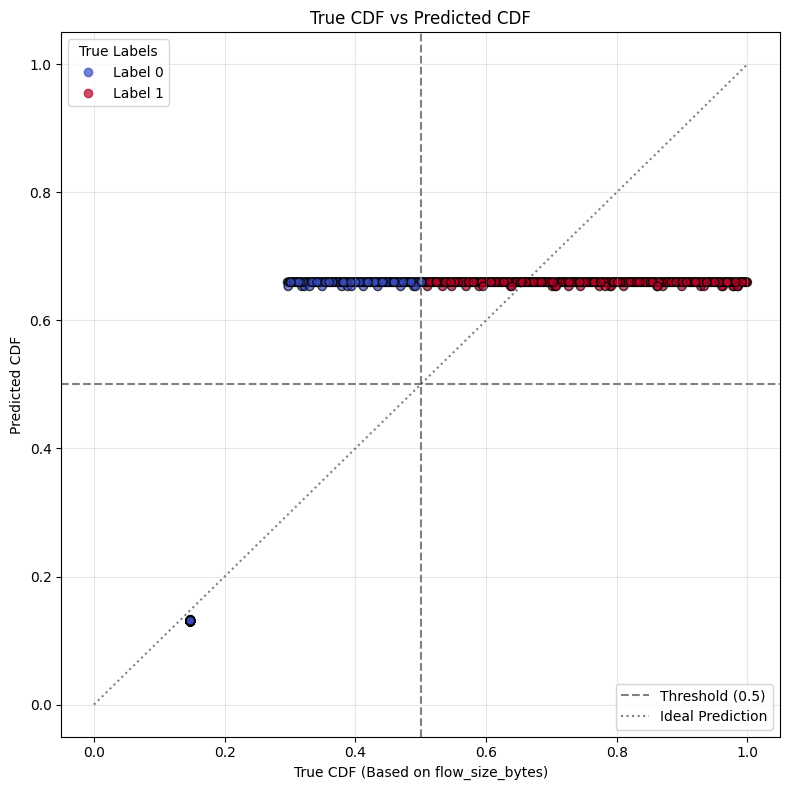

In [ ]:
import json
import torch
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from models import DiffEarlyExitGRU

def load_test_data(jsonl_file):
    directions, xs, flow_sizes, labels = [], [], [], []
    
    with open(jsonl_file, 'r') as f:
        for line in f:
            item = json.loads(line)
            dir_str = item["flow_key"]["direction"]
            dir_idx = 0 if dir_str == "src_to_dst" else 1
            
            xs.append(np.array(item["x"], dtype=np.float32))
            directions.append(dir_idx)
            flow_sizes.append(item["flow_size_bytes"])
            labels.append(item["label"])
            
    # 정규화 (테스트셋 내 정규화 혹은 학습셋의 min/max를 불러와 적용)
    all_x = np.vstack(xs)
    x_min = np.min(all_x, axis=0)
    x_max = np.max(all_x, axis=0)
    range_val = x_max - x_min
    range_val[range_val == 0] = 1.0 
    
    for i in range(len(xs)):
        xs[i] = (xs[i] - x_min) / range_val
        
    # True CDF 계산
    ranks = rankdata(flow_sizes, method='average')
    true_cdfs = (ranks - 1) / (len(flow_sizes) - 1) if len(flow_sizes) > 1 else np.array([0.0])
    
    return xs, directions, true_cdfs, labels

def evaluate_model(model_path, test_file):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. 모델 로드
    model = DiffEarlyExitGRU(input_size=11, hidden_size=64).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. 데이터 로드
    xs, directions, true_cdfs, labels = load_test_data(test_file)
    
    pred_cdfs = []
    inference_times = []
    exit_steps = []
    
    print("Starting Inference...")
    
    # 3. 추론 및 시간 측정
    with torch.no_grad():
        for i in range(len(xs)):
            x_tensor = torch.tensor(xs[i]).unsqueeze(0).to(device) # (1, seq_len, 11)
            dir_tensor = torch.tensor([directions[i]]).to(device)  # (1,)
            
            # 추론 시간 측정 시작
            start_time = time.perf_counter()
            
            # 예측 수행 (Early Exit 활성화)
            pred, step = model(x_tensor, dir_tensor, enable_early_exit=True, tolerance=0.01)
            
            # 추론 시간 측정 종료
            end_time = time.perf_counter()
            
            pred_cdfs.append(pred)
            exit_steps.append(step)
            inference_times.append((end_time - start_time) * 1000) # 밀리초(ms) 단위 변환

    # --- [결과 계산 및 출력] ---
    
    # 시간 및 Time Step 통계
    min_time = np.min(inference_times)
    max_time = np.max(inference_times)
    avg_time = np.mean(inference_times)
    avg_steps = np.mean(exit_steps)
    
    print("-" * 40)
    print("[Inference Profiling]")
    print(f"Min Time:  {min_time:.4f} ms")
    print(f"Max Time:  {max_time:.4f} ms")
    print(f"Avg Time:  {avg_time:.4f} ms")
    print(f"Avg Steps: {avg_steps:.2f} packets before early exit")
    
    # [수정된 부분] 0.5 임계값 설정
    threshold = 0.5
    
    # 실제 CDF와 예측 CDF가 모두 threshold 이상인지 여부를 T/F(1/0)로 변환
    true_binary = (np.array(true_cdfs) >= threshold).astype(int)
    pred_binary = (np.array(pred_cdfs) >= threshold).astype(int)
    
    acc = accuracy_score(true_binary, pred_binary)
    prec = precision_score(true_binary, pred_binary, zero_division=0)
    rec = recall_score(true_binary, pred_binary, zero_division=0)
    f1 = f1_score(true_binary, pred_binary, zero_division=0)
    
    print("-" * 40)
    print(f"[Classification Metrics (Threshold = {threshold})]")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 40)
    
    # --- [산점도 시각화] ---
    plt.figure(figsize=(8, 8))
    
    scatter = plt.scatter(true_cdfs, pred_cdfs, c=labels, cmap='coolwarm', alpha=0.7, edgecolors='k')
    
    plt.axvline(x=threshold, color='gray', linestyle='--', label=f'Threshold ({threshold})')
    plt.axhline(y=threshold, color='gray', linestyle='--')
    
    plt.plot([0, 1], [0, 1], color='black', linestyle=':', alpha=0.5, label='Ideal Prediction')
    
    plt.title('True CDF vs Predicted CDF')
    plt.xlabel('True CDF (Based on flow_size_bytes)')
    plt.ylabel('Predicted CDF')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    
    handles, _ = scatter.legend_elements()
    legend1 = plt.legend(handles, ["Label 0", "Label 1"], title="True Labels", loc="upper left")
    plt.gca().add_artist(legend1)
    
    # 기타 기준선들에 대한 범례
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    evaluate_model(model_path='diff_early_exit_gru_mininet.pth', test_file='mininet_test.jsonl')
    pass